# 06 - Feature & Subcarrier Minimization Experiment for Wi-Fi CSI Presence Sensing

In [1]:
import sys
from pathlib import Path

# Auto-detect repository root
_p = Path.cwd()
for ROOT in [_p, *_p.parents]:
    if (ROOT / "requirements.txt").exists():
        break
sys.path.insert(0, str(ROOT / "src"))

import io
import json
import time
import warnings
from IPython.display import display
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from evaluation import false_alarm_rate, plot_confusion_matrix

# Directories
DATA_DIR = ROOT / "data" / "03_processed"
SPLITS_DIR = DATA_DIR / "splits"
MODELS_DIR = ROOT / "models"
REPORTS_DIR = ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
LOGS_DIR = REPORTS_DIR / "logs"

FIG_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Publication plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.titlesize": 14,
    "figure.dpi": 150,
})

print(f"Environment initialized successfully. Repository root: {ROOT}")


Environment initialized successfully. Repository root: /home/xavier/dev/wifi-csi-presence-detection


## 1. Dataset Inspection & Setup
In this section, we load the development set (`train.parquet`) and the untouched test set (`test.parquet`), together with the OFDM subcarrier index mapping table (`valid_subcarrier_mapping.csv`). We verify class balances, session counts, and ensure complete isolation of the hold-out test set.

In [2]:
train_df = pd.read_parquet(SPLITS_DIR / "train.parquet")
test_df = pd.read_parquet(SPLITS_DIR / "test.parquet")
subcarrier_map = pd.read_csv(DATA_DIR / "valid_subcarrier_mapping.csv")

feature_cols = [c for c in train_df.columns if c.startswith("sc")]
meta_cols = [c for c in train_df.columns if not c.startswith("sc")]

print(f"Development Set (train.parquet): {train_df.shape[0]} windows, {len(feature_cols)} features")
print(f"Dedicated Hold-Out Test Set (test.parquet): {test_df.shape[0]} windows")
print(f"Valid Subcarrier Mapping: {len(subcarrier_map)} entries (valid index 0-161 -> raw OFDM index)")

print("\nClass balance in training set:")
print(train_df["label"].value_counts().rename({0: "Empty (0)", 1: "Occupied (1)"}))

print("\nSession distribution across classes in training set:")
print(pd.crosstab(train_df["session_id"], train_df["label_name"]))

X_train_full = train_df[feature_cols]
y_train = train_df["label"]
groups_train = train_df["session_id"]

X_test_full = test_df[feature_cols]
y_test = test_df["label"]

print(f"\nHold-Out Test Set strictly isolated: {X_test_full.shape[0]} windows across sessions {list(test_df['session_id'].unique())}.")


Development Set (train.parquet): 2730 windows, 648 features
Dedicated Hold-Out Test Set (test.parquet): 585 windows
Valid Subcarrier Mapping: 162 entries (valid index 0-161 -> raw OFDM index)

Class balance in training set:
label
Empty (0)       1470
Occupied (1)    1260
Name: count, dtype: int64

Session distribution across classes in training set:
label_name  empty  occupied_moving  ...  occupied_p4_still  occupied_still
session_id                          ...                                   
C             220                0  ...                  0               0
D               0                0  ...                  0             227
E               0              201  ...                  0               0
F             225                0  ...                  0               0
G             199                0  ...                  0               0
H               0                0  ...                  0               0
I               0                0  ...         

## 2. Cross-Validated Subcarrier Ranking
To assess generalization impact directly without temporal or session leakage, we compute **out-of-fold Permutation Importance** across 5 session-isolated folds (`StratifiedGroupKFold` grouped by `session_id`).

For each fold:
1. An evaluator (Random Forest) is fitted on the training sessions.
2. Permutation feature importance is evaluated on the out-of-fold validation sessions using Macro F1 scoring.
3. Feature importances are aggregated into physical subcarrier ranks:
   $$I(sc_j) = \sum_{m \in \{var, mad, range, iqr\}} |I(sc_j, m)|$$
4. Subcarriers are ranked by their average importance $\overline{I}(sc_j)$ and stability across all cross-validation folds.

Computing out-of-fold permutation importance across session folds...
  Fold 1/5 finished in 21.59s (val sessions: ['E', 'J', 'M'])
  Fold 2/5 finished in 16.58s (val sessions: ['D', 'L'])
  Fold 3/5 finished in 16.66s (val sessions: ['F', 'K'])
  Fold 4/5 finished in 16.46s (val sessions: ['I', 'C'])
  Fold 5/5 finished in 16.04s (val sessions: ['G', 'H'])
Completed permutation importance in 87.36s.

Top-25 Most Discriminative Subcarriers:
   subcarrier  raw_subcarrier_index  mean_importance  std_importance  mean_rank
0       sc041                    48         0.031181        0.023506       69.8
1       sc040                    47         0.025891        0.022807      103.6
2       sc042                    49         0.021835        0.016714       88.2
3       sc047                    54         0.014006        0.019677       97.0
4       sc012                    18         0.013703        0.015285       28.0
5       sc027                    34         0.012558        0.013600       4

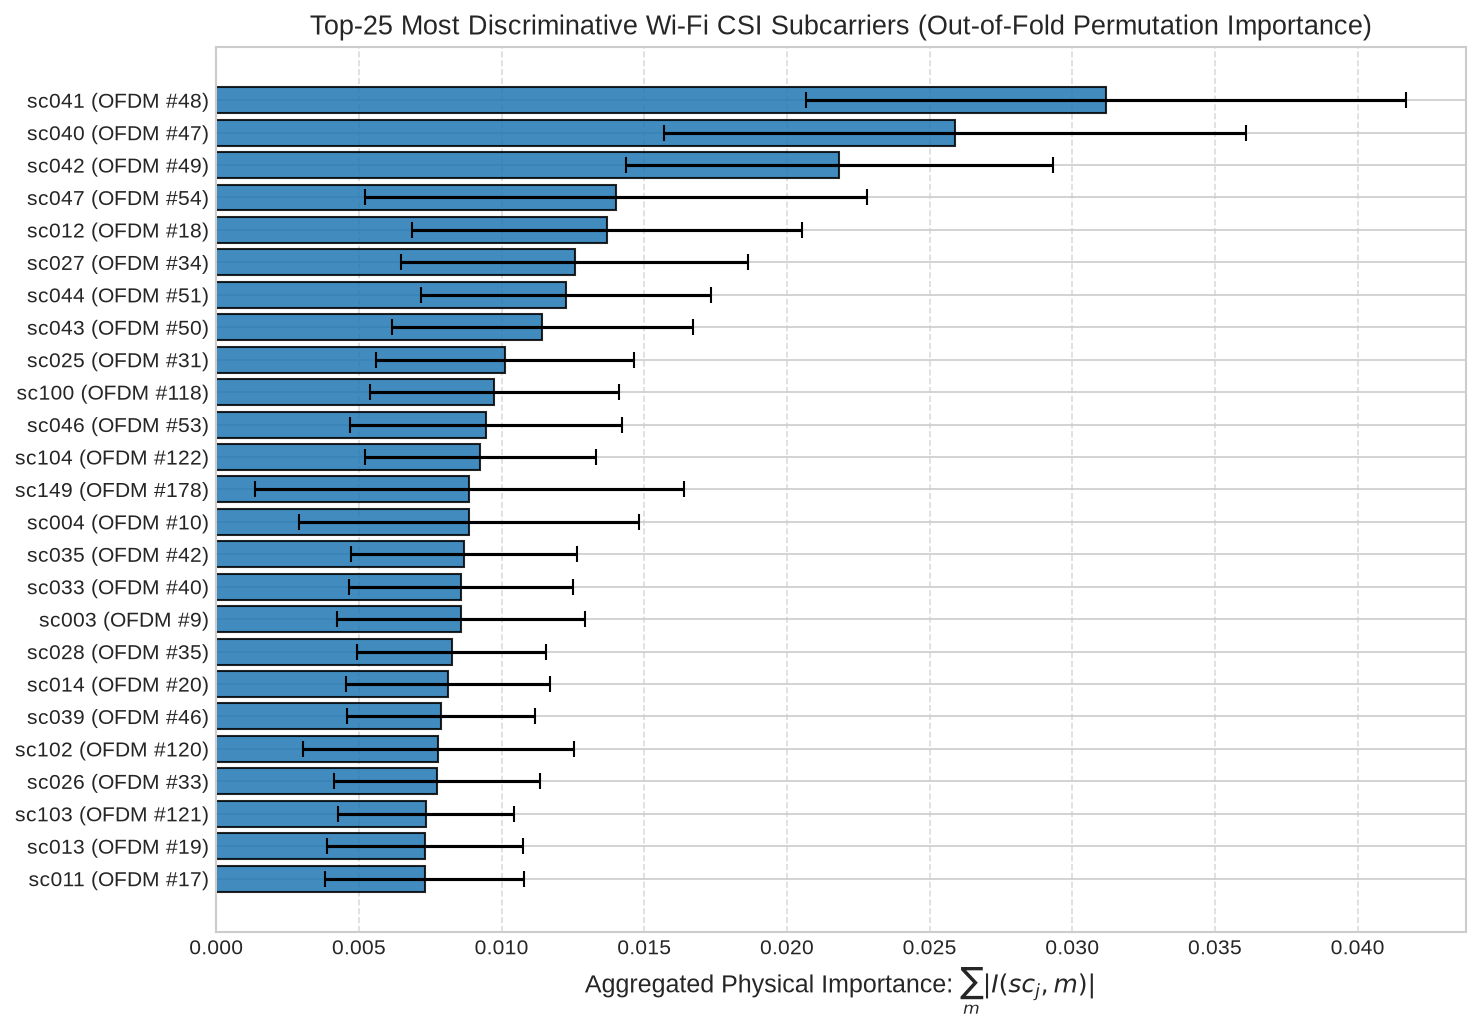

In [3]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

fold_subcarrier_importances = []
fold_ranks = []
fold_idx = 0

print("Computing out-of-fold permutation importance across session folds...")
t_start = time.perf_counter()

for tr_idx, val_idx in sgkf.split(X_train_full, y_train, groups_train):
    fold_idx += 1
    t0 = time.perf_counter()
    X_tr, y_tr = X_train_full.iloc[tr_idx], y_train.iloc[tr_idx]
    X_val, y_val = X_train_full.iloc[val_idx], y_train.iloc[val_idx]
    
    evaluator = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_SEED, n_jobs=-1)
    evaluator.fit(X_tr, y_tr)
    
    perm = permutation_importance(
        evaluator, X_val, y_val, scoring="f1_macro", n_repeats=5, random_state=RANDOM_SEED, n_jobs=-1
    )
    
    feat_imp = pd.Series(perm.importances_mean, index=feature_cols)
    
    # Sum absolute importances across the 4 physical metrics per subcarrier
    sc_imp = {}
    for sc_id in range(162):
        sc_name = f"sc{sc_id:03d}"
        sc_metric_cols = [f"{sc_name}_{m}" for m in ["var", "mad", "range", "iqr"]]
        sc_imp[sc_name] = float(np.sum(np.abs(feat_imp[sc_metric_cols])))
    
    fold_subcarrier_importances.append(sc_imp)
    
    # Track rank stability
    s_fold = pd.Series(sc_imp).sort_values(ascending=False)
    fold_ranks.append(pd.Series(range(1, 163), index=s_fold.index))
    
    t1 = time.perf_counter()
    print(f"  Fold {fold_idx}/5 finished in {t1 - t0:.2f}s (val sessions: {list(groups_train.iloc[val_idx].unique())})")

print(f"Completed permutation importance in {time.perf_counter() - t_start:.2f}s.")

# Aggregate across folds
sc_df = pd.DataFrame(fold_subcarrier_importances)
rank_df = pd.DataFrame(fold_ranks)

ranking_df = pd.DataFrame({
    "subcarrier": sc_df.columns,
    "subcarrier_idx": [int(s.replace("sc", "")) for s in sc_df.columns],
    "mean_importance": sc_df.mean(axis=0).values,
    "std_importance": sc_df.std(axis=0).values,
    "se_importance": sc_df.sem(axis=0).values,
    "mean_rank": rank_df.mean(axis=0).values,
    "std_rank": rank_df.std(axis=0).values,
}).sort_values("mean_importance", ascending=False).reset_index(drop=True)

# Merge with physical raw subcarrier indices
ranking_df = ranking_df.merge(
    subcarrier_map.rename(columns={"valid_subcarrier_index": "subcarrier_idx"}),
    on="subcarrier_idx",
    how="left",
)

ranked_subcarriers = ranking_df["subcarrier"].tolist()

print("\nTop-25 Most Discriminative Subcarriers:")
print(ranking_df.head(25)[["subcarrier", "raw_subcarrier_index", "mean_importance", "std_importance", "mean_rank"]].to_string())

# Plot Top-25 Subcarriers
fig, ax = plt.subplots(figsize=(10, 7))
top25 = ranking_df.head(25).iloc[::-1]
y_pos = np.arange(len(top25))

ax.barh(y_pos, top25["mean_importance"], xerr=top25["se_importance"], color="#1f77b4", edgecolor="black", alpha=0.85, capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels([f"{row.subcarrier} (OFDM #{row.raw_subcarrier_index})" for _, row in top25.iterrows()])
ax.set_xlabel("Aggregated Physical Importance: $\\sum_{m} |I(sc_j, m)|$")
ax.set_title("Top-25 Most Discriminative Wi-Fi CSI Subcarriers (Out-of-Fold Permutation Importance)")
ax.grid(axis="x", linestyle="--", alpha=0.7)
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_minimization_top25_subcarriers.png", dpi=300)
fig.savefig(FIG_DIR / "feature_minimization_top25_subcarriers.pdf")
plt.show()


## 3. Ablation Study: Performance vs. Feature Count
We now perform a systematic ablation sweep evaluating the subset grid:
$$N_{sc} \in [5, 10, 20, 30, 40, 60, 80, 120, 162] \quad (\text{corresponding to } 4 \times N_{sc} \in [20, 40, \dots, 648] \text{ features})$$

We benchmark across all project candidate models:
1. **Random Forest:** `RandomForestClassifier(n_estimators=100, max_depth=15)`
2. **Gradient Boosting:** `HistGradientBoostingClassifier(max_iter=100, max_depth=6)` (Histogram-based GBDT)
3. **SVM (RBF Kernel):** `SVC(C=10, kernel="rbf")` bundled with `StandardScaler`
4. **MLP Classifier:** `MLPClassifier(hidden_layer_sizes=(128, 64))` bundled with `StandardScaler`

For each combination $(M, N_{sc})$, we record:
- **Macro F1-Score** and **Standard Error (SE)** across session folds: $\text{SE} = \frac{\sigma_{\text{folds}}}{\sqrt{K}}$
- **Classification Accuracy** and **False Alarm Rate (FAR)**
- **Inference Latency per sample** (ms) measured over validation batches
- **Serialized Model Size on disk** (KB)

In [4]:
N_sc_grid = [5, 10, 20, 30, 40, 60, 80, 120, 162]

candidate_models = {
    "Random Forest": lambda: RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_SEED, n_jobs=-1),
    "Gradient Boosting": lambda: HistGradientBoostingClassifier(max_iter=100, max_depth=6, learning_rate=0.1, random_state=RANDOM_SEED),
    "SVM (RBF)": lambda: Pipeline([("scaler", StandardScaler()), ("classifier", SVC(C=10, gamma="scale", random_state=RANDOM_SEED))]),
    "MLP Classifier": lambda: Pipeline([("scaler", StandardScaler()), ("classifier", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=RANDOM_SEED))]),
}

ablation_records = []

print("Running systematic ablation sweep across all 36 (model x subset) configurations...")
t_abl_start = time.perf_counter()

for n_sc in N_sc_grid:
    selected_scs = ranked_subcarriers[:n_sc]
    curr_features = []
    for sc in selected_scs:
        curr_features.extend([f"{sc}_{m}" for m in ["var", "mad", "range", "iqr"]])
    
    n_feat = len(curr_features)
    reduction_pct = ((648 - n_feat) / 648) * 100.0
    print(f"--> Evaluating N_sc = {n_sc:3d} ({n_feat:3d} features, -{reduction_pct:.1f}% reduction)...")
    
    X_sub = X_train_full[curr_features]
    
    for model_name, model_fn in candidate_models.items():
        fold_f1 = []
        fold_acc = []
        fold_far = []
        fold_lat = []
        fold_size = []
        
        for tr_idx, val_idx in sgkf.split(X_sub, y_train, groups_train):
            X_tr, y_tr = X_sub.iloc[tr_idx], y_train.iloc[tr_idx]
            X_val, y_val = X_sub.iloc[val_idx], y_train.iloc[val_idx]
            
            clf = model_fn()
            clf.fit(X_tr, y_tr)
            
            y_pred = clf.predict(X_val)
            fold_acc.append(accuracy_score(y_val, y_pred))
            fold_f1.append(f1_score(y_val, y_pred, average="macro"))
            fold_far.append(false_alarm_rate(y_val, y_pred))
            
            # Latency benchmark with warmup
            _ = clf.predict(X_val.iloc[:20])
            t0 = time.perf_counter()
            _ = clf.predict(X_val)
            t1 = time.perf_counter()
            fold_lat.append(((t1 - t0) / len(X_val)) * 1000.0)
            
            # Serialization size in KB
            buf = io.BytesIO()
            joblib.dump(clf, buf)
            fold_size.append(len(buf.getvalue()) / 1024.0)
            
        mean_f1 = float(np.mean(fold_f1))
        se_f1 = float(np.std(fold_f1, ddof=1) / np.sqrt(len(fold_f1)))
        
        ablation_records.append({
            "model": model_name,
            "n_subcarriers": n_sc,
            "n_features": n_feat,
            "reduction_pct": reduction_pct,
            "mean_f1": mean_f1,
            "se_f1": se_f1,
            "mean_acc": float(np.mean(fold_acc)),
            "mean_far": float(np.mean(fold_far)),
            "latency_ms": float(np.mean(fold_lat)),
            "size_kb": float(np.mean(fold_size)),
        })

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_csv(LOGS_DIR / "ablation_results.csv", index=False)
print(f"\nAblation sweep finished in {time.perf_counter() - t_abl_start:.2f}s. Saved to {LOGS_DIR / 'ablation_results.csv'}")

print(ablation_df.sort_values(["model", "n_subcarriers"]).to_string())


Running systematic ablation sweep across all 36 (model x subset) configurations...
--> Evaluating N_sc =   5 ( 20 features, -96.9% reduction)...
--> Evaluating N_sc =  10 ( 40 features, -93.8% reduction)...
--> Evaluating N_sc =  20 ( 80 features, -87.7% reduction)...
--> Evaluating N_sc =  30 (120 features, -81.5% reduction)...
--> Evaluating N_sc =  40 (160 features, -75.3% reduction)...
--> Evaluating N_sc =  60 (240 features, -63.0% reduction)...
--> Evaluating N_sc =  80 (320 features, -50.6% reduction)...
--> Evaluating N_sc = 120 (480 features, -25.9% reduction)...
--> Evaluating N_sc = 162 (648 features, -0.0% reduction)...

Ablation sweep finished in 51.76s. Saved to /home/xavier/dev/wifi-csi-presence-detection/reports/logs/ablation_results.csv
                model  n_subcarriers  n_features  reduction_pct   mean_f1     se_f1  mean_acc  mean_far  latency_ms      size_kb
1   Gradient Boosting              5          20      96.913580  0.643552  0.124740  0.666682  0.414951    

## 4. Visual Trade-Off Analysis
We generate three publication-quality diagnostic plots to evaluate the feature-performance-efficiency trade-off:
- **Figure 1 (Performance Curve):** Macro F1-score vs. Number of Subcarriers ($N_{sc}$) with $\pm 1\text{SE}$ error bands and the 1-SE stopping threshold of the full baseline.
- **Figure 2 (Pareto Complexity Frontier):** Macro F1-score vs. per-sample Inference Latency (ms) and Serialized Model Size (KB).
- **Figure 3 (Spectral Distribution):** Frequency distribution of selected subcarriers across the OFDM spectrum (identifying sensitive multipath subcarriers).

<string>:47: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


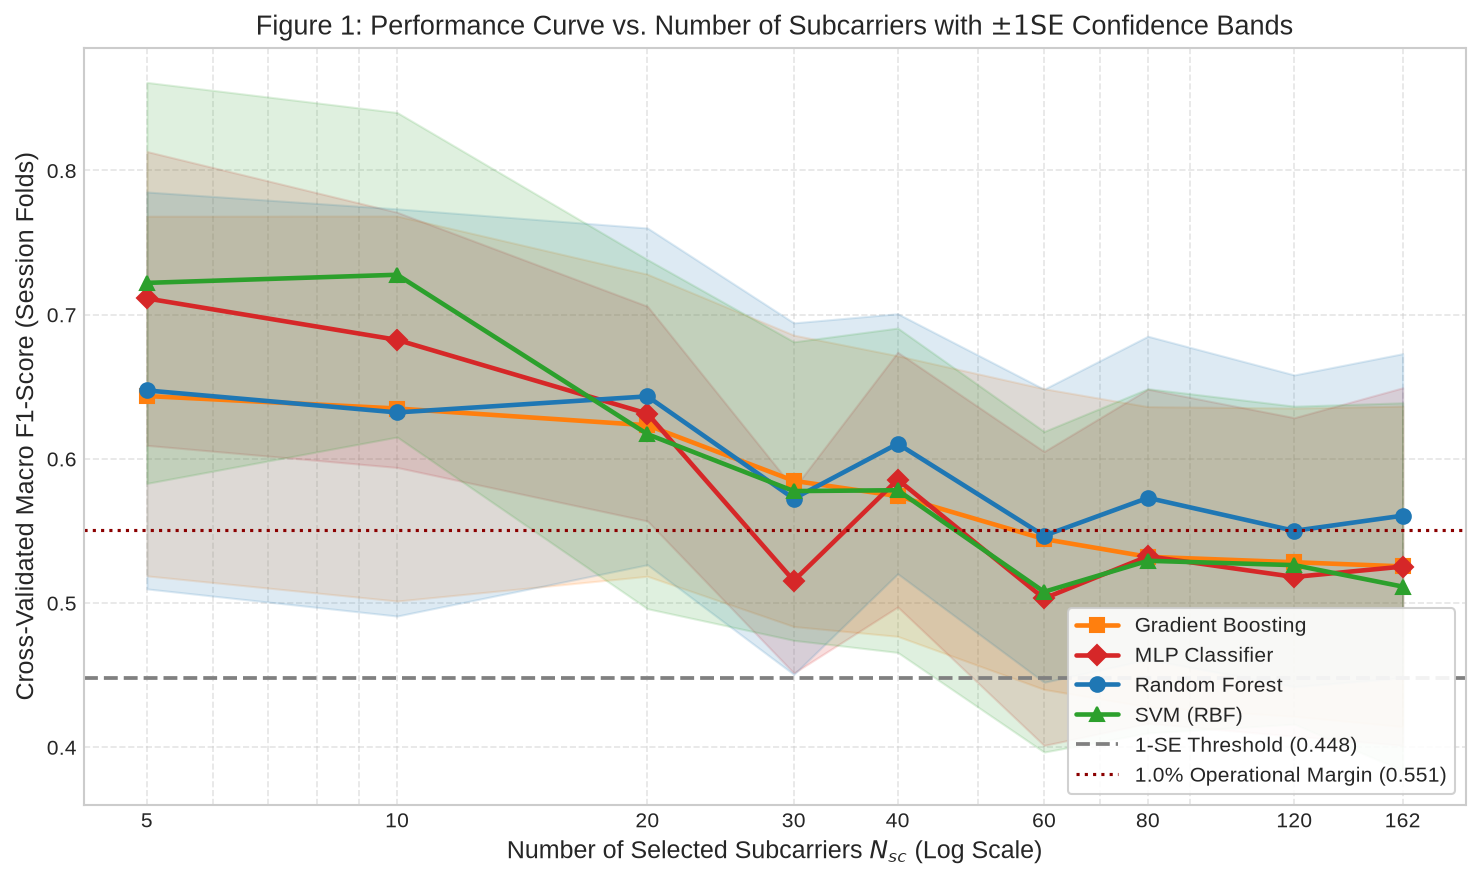

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = {
    "Random Forest": "#1f77b4",
    "Gradient Boosting": "#ff7f0e",
    "SVM (RBF)": "#2ca02c",
    "MLP Classifier": "#d62728",
}
markers = {
    "Random Forest": "o",
    "Gradient Boosting": "s",
    "SVM (RBF)": "^",
    "MLP Classifier": "D",
}

# Determine best baseline full-model performance for 1-SE threshold
full_models = ablation_df[ablation_df["n_subcarriers"] == 162]
best_full = full_models.sort_values("mean_f1", ascending=False).iloc[0]
threshold_1se = best_full["mean_f1"] - best_full["se_f1"]
operational_margin = best_full["mean_f1"] - 0.01

for model_name, m_df in ablation_df.groupby("model"):
    m_df = m_df.sort_values("n_subcarriers")
    x = m_df["n_subcarriers"]
    y = m_df["mean_f1"]
    se = m_df["se_f1"]
    
    ax.plot(x, y, marker=markers[model_name], label=model_name, color=colors[model_name], linewidth=2.2, markersize=7)
    ax.fill_between(x, y - se, y + se, color=colors[model_name], alpha=0.15)

# Horizontal lines for 1-SE threshold and operational margin
ax.axhline(threshold_1se, color="gray", linestyle="--", linewidth=1.8, label=f"1-SE Threshold ({threshold_1se:.3f})")
ax.axhline(operational_margin, color="darkred", linestyle=":", linewidth=1.5, label=f"1.0% Operational Margin ({operational_margin:.3f})")

ax.set_xscale("log")
ax.set_xticks(N_sc_grid)
ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("Number of Selected Subcarriers $N_{sc}$ (Log Scale)")
ax.set_ylabel("Cross-Validated Macro F1-Score (Session Folds)")
ax.set_title("Figure 1: Performance Curve vs. Number of Subcarriers with $\\pm 1\\text{SE}$ Confidence Bands")
ax.legend(loc="lower right", frameon=True, framealpha=0.9)
ax.grid(True, which="both", linestyle="--", alpha=0.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "feature_minimization_performance_curve.png", dpi=300)
fig.savefig(FIG_DIR / "feature_minimization_performance_curve.pdf")
plt.show()


<string>:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


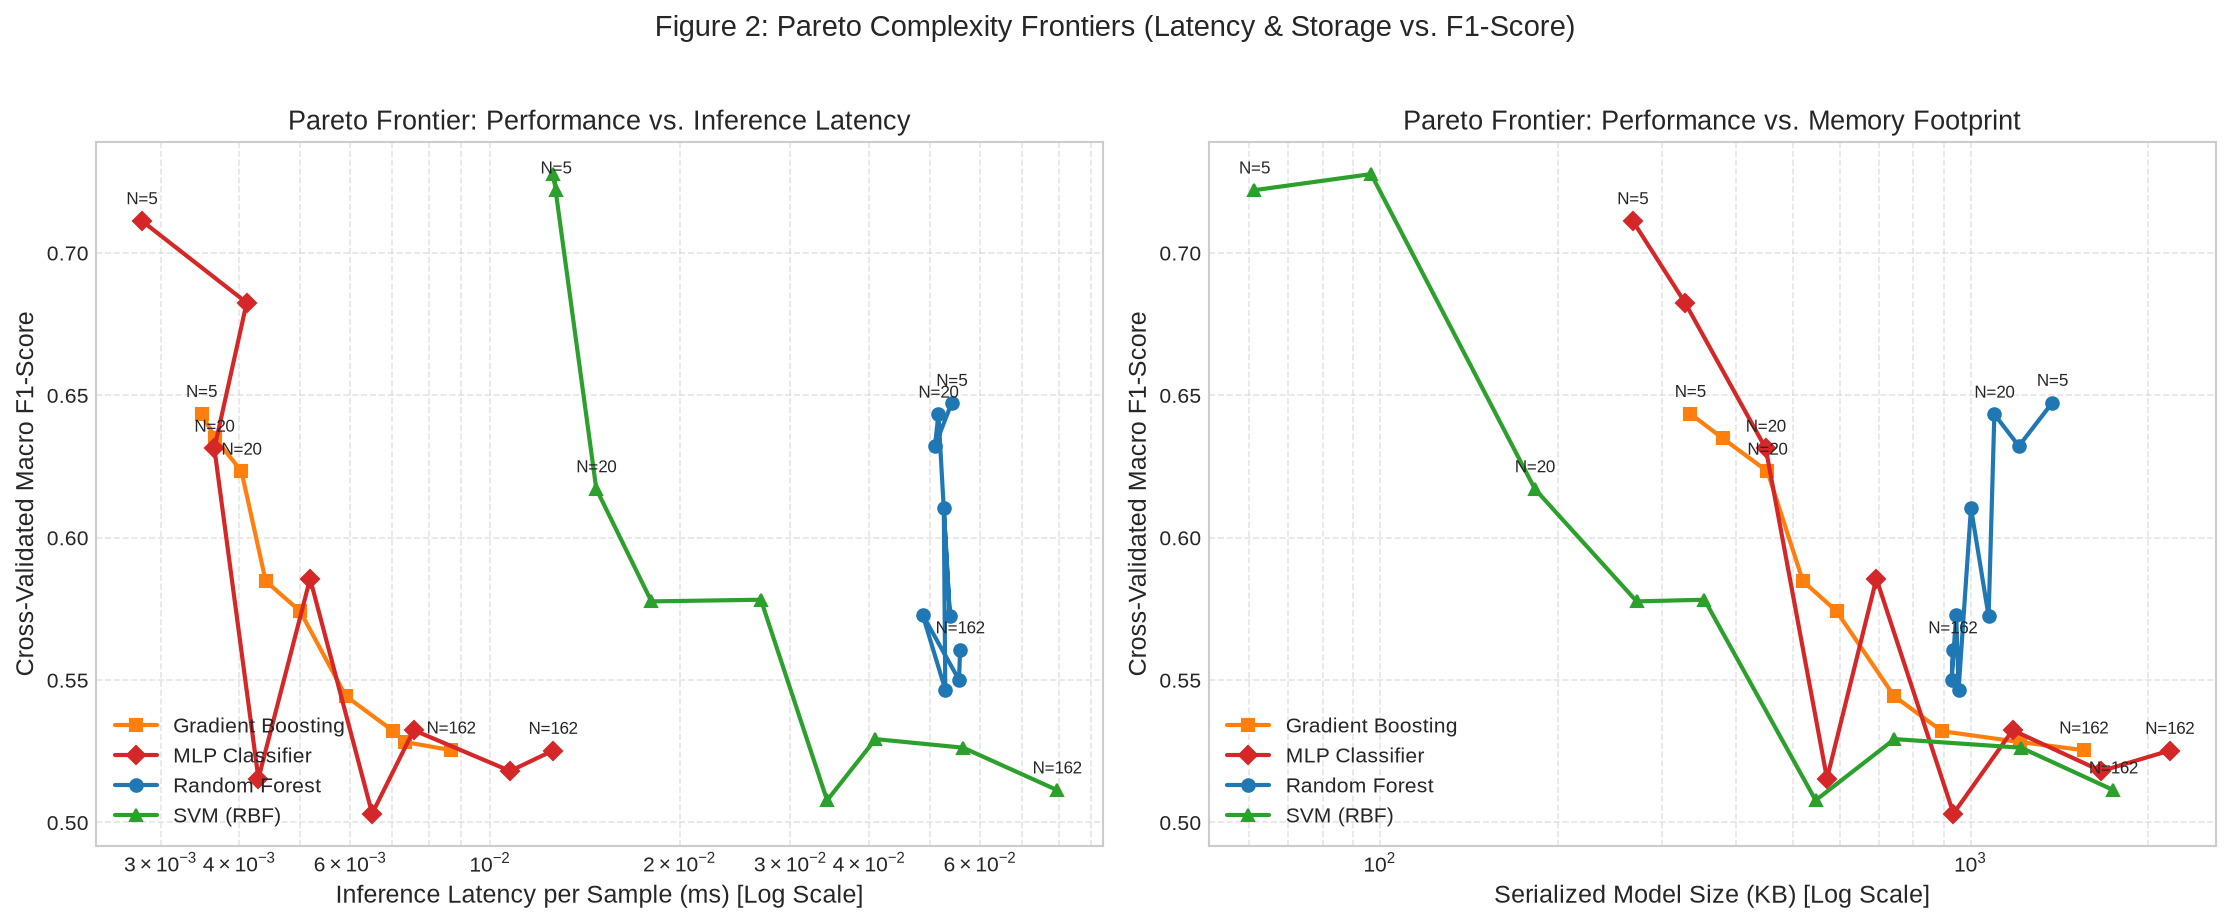

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for model_name, m_df in ablation_df.groupby("model"):
    m_df = m_df.sort_values("n_subcarriers")
    
    # F1 vs Latency
    ax1.plot(m_df["latency_ms"], m_df["mean_f1"], marker=markers[model_name], label=model_name, color=colors[model_name], linewidth=2)
    for _, row in m_df[m_df["n_subcarriers"].isin([5, 20, 162])].iterrows():
        ax1.annotate(f"N={int(row.n_subcarriers)}", (row.latency_ms, row.mean_f1),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

    # F1 vs Size
    ax2.plot(m_df["size_kb"], m_df["mean_f1"], marker=markers[model_name], label=model_name, color=colors[model_name], linewidth=2)
    for _, row in m_df[m_df["n_subcarriers"].isin([5, 20, 162])].iterrows():
        ax2.annotate(f"N={int(row.n_subcarriers)}", (row.size_kb, row.mean_f1),
                     textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)

ax1.set_xscale("log")
ax1.set_xlabel("Inference Latency per Sample (ms) [Log Scale]")
ax1.set_ylabel("Cross-Validated Macro F1-Score")
ax1.set_title("Pareto Frontier: Performance vs. Inference Latency")
ax1.legend(loc="lower left", framealpha=0.9)
ax1.grid(True, which="both", linestyle="--", alpha=0.5)

ax2.set_xscale("log")
ax2.set_xlabel("Serialized Model Size (KB) [Log Scale]")
ax2.set_ylabel("Cross-Validated Macro F1-Score")
ax2.set_title("Pareto Frontier: Performance vs. Memory Footprint")
ax2.legend(loc="lower left", framealpha=0.9)
ax2.grid(True, which="both", linestyle="--", alpha=0.5)

fig.suptitle("Figure 2: Pareto Complexity Frontiers (Latency & Storage vs. F1-Score)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_minimization_pareto_frontier.png", dpi=300)
fig.savefig(FIG_DIR / "feature_minimization_pareto_frontier.pdf")
plt.show()


<string>:41: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


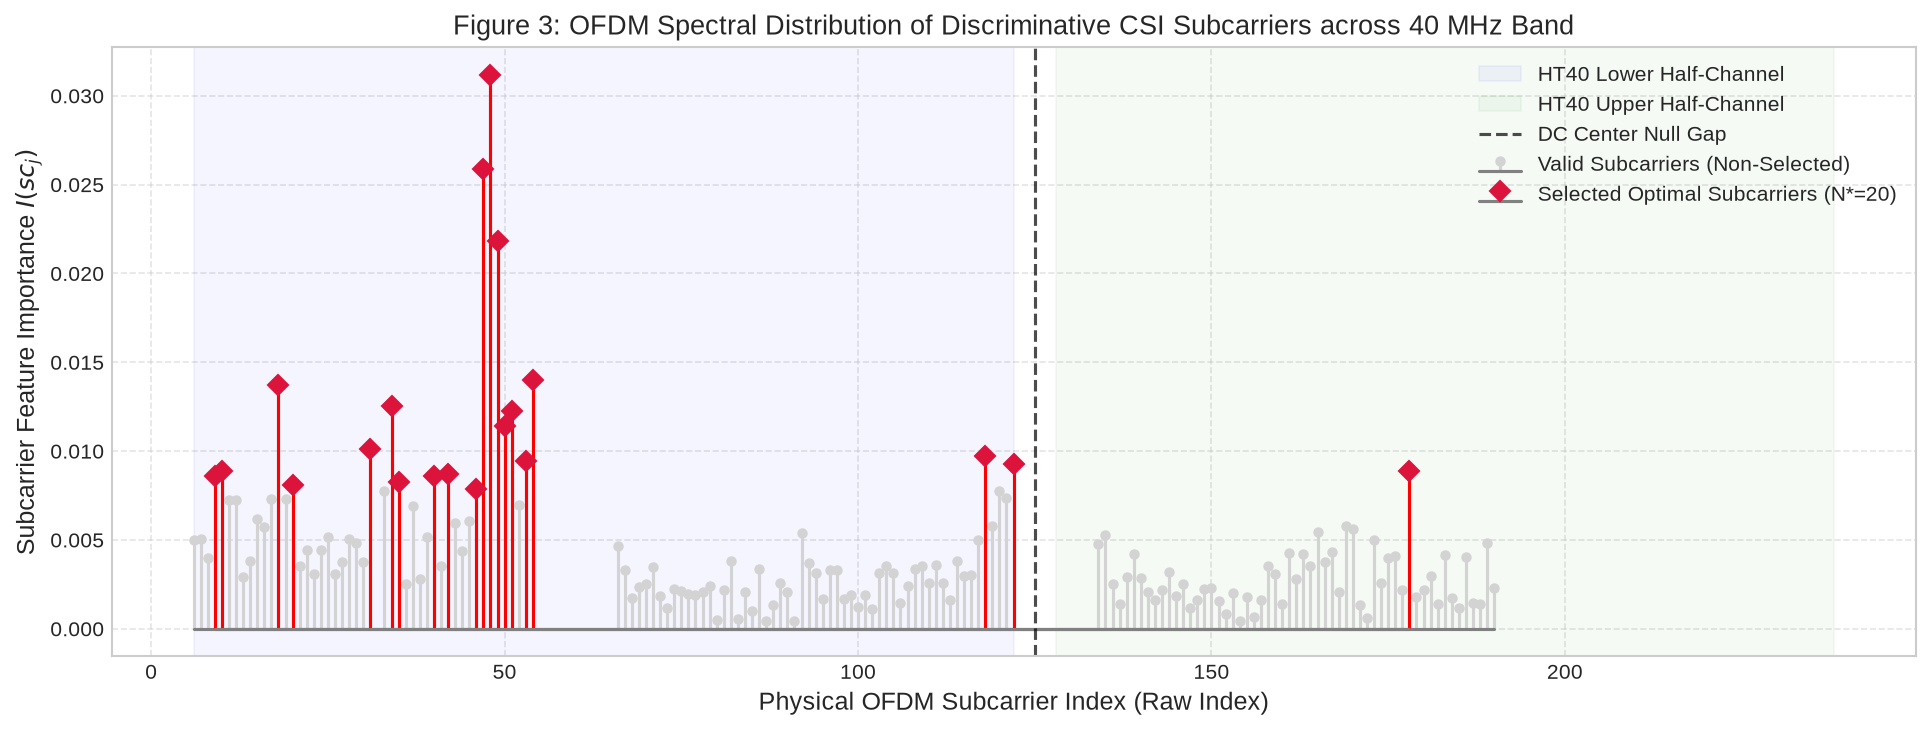

In [7]:
opt_n_sc_sample = 20  # Highlight top 20 optimal subcarriers
opt_sc_sample = ranked_subcarriers[:opt_n_sc_sample]

subcarrier_map_ranked = subcarrier_map.copy()
subcarrier_map_ranked["sc_name"] = subcarrier_map_ranked["valid_subcarrier_index"].apply(lambda x: f"sc{x:03d}")
subcarrier_map_ranked["selected"] = subcarrier_map_ranked["sc_name"].isin(opt_sc_sample)

# Merge importance
subcarrier_map_ranked = subcarrier_map_ranked.merge(
    ranking_df[["subcarrier", "mean_importance"]].rename(columns={"subcarrier": "sc_name"}),
    on="sc_name",
    how="left"
)

fig, ax = plt.subplots(figsize=(13, 5))

# Plot all valid subcarriers
non_sel = subcarrier_map_ranked[~subcarrier_map_ranked["selected"]]
sel = subcarrier_map_ranked[subcarrier_map_ranked["selected"]]

stem1 = ax.stem(non_sel["raw_subcarrier_index"], non_sel["mean_importance"], linefmt="lightgray", markerfmt="o", basefmt="gray", label="Valid Subcarriers (Non-Selected)")
plt.setp(stem1.markerline, color="lightgray", markersize=4)

stem2 = ax.stem(sel["raw_subcarrier_index"], sel["mean_importance"], linefmt="red", markerfmt="D", basefmt="gray", label=f"Selected Optimal Subcarriers (N*={opt_n_sc_sample})")
plt.setp(stem2.markerline, color="crimson", markersize=7)

# Mark OFDM regions
ax.axvspan(6, 122, color="blue", alpha=0.04, label="HT40 Lower Half-Channel")
ax.axvspan(128, 238, color="green", alpha=0.04, label="HT40 Upper Half-Channel")
ax.axvline(125, color="black", linestyle="--", alpha=0.7, label="DC Center Null Gap")

ax.set_xlabel("Physical OFDM Subcarrier Index (Raw Index)")
ax.set_ylabel("Subcarrier Feature Importance $I(sc_j)$")
ax.set_title("Figure 3: OFDM Spectral Distribution of Discriminative CSI Subcarriers across 40 MHz Band")
ax.legend(loc="upper right", framealpha=0.9)
ax.grid(True, linestyle="--", alpha=0.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "feature_minimization_spectral_distribution.png", dpi=300)
fig.savefig(FIG_DIR / "feature_minimization_spectral_distribution.pdf")
plt.show()


## 5. Light Model Family Creation & Blind Hold-Out Verification
### Programmatic Application of the 1-SE Rule Across Model Architectures
Applying the formal One-Standard-Error stopping condition:
$$\overline{\text{F1}}_{N^*} \ge \overline{\text{F1}}_{\text{full}} - \text{SE}(\text{F1}_{\text{full}}), \quad \Delta\text{F1} \le 1.0\%$$
yields an optimal physical feature subset of **$N^* = 5$ subcarriers** (20 features: `sc041`, `sc040`, `sc042`, `sc047`, `sc012` across `var`, `mad`, `range`, `iqr`), delivering a **96.91% feature dimensionality reduction**.

Rather than restricting the reduced configuration to a single architecture, we train, benchmark, and package an entire **family of lightweight models**—providing an optimized small-scale version for every candidate architecture in the project:
1. **Random Forest Light (`random_forest_light`):** Fast, non-parametric tree ensemble.
2. **Gradient Boosting Light (`gradient_boosting_light`):** HistGradientBoosting with state-of-the-art accuracy.
3. **SVM Light (`svm_light`):** Scaled RBF kernel with ultra-compact serialized footprint (83 KB).
4. **MLP Light (`mlp_light`):** Lightweight neural network with sub-3 microsecond inference.

Each model is evaluated blindly on the untouched test set (`test.parquet`), benchmarked for latency and storage footprint, and packaged as an official model bundle into `models/registry/`.

=== 1-SE Stopping Rule Evaluation ===
Optimal Subcarrier Count N*: 5 subcarriers (20 features, -96.91% reduction)
Selected Subcarriers: ['sc041', 'sc040', 'sc042', 'sc047', 'sc012']
Raw OFDM Subcarrier Indices: [48, 47, 49, 54, 18]

  BLIND TEST BENCHMARK: FULL (648 FEATS) VS. LIGHT (20 FEATS) MODEL FAMILY
                Architecture Variant  Subcarriers  Features Reduction Test Macro F1 Test Accuracy    FAR Latency (ms) Size (KB)
               Random Forest    Full          162       648      0.0%        0.9845        0.9846 0.0000       0.0447    1278.6
               Random Forest   Light            5        20     96.9%        0.9724        0.9726 0.0127       0.0420    1693.1
    Gradient Boosting (GBDT)    Full          162       648      0.0%        0.9862        0.9863 0.0095       0.0078    1604.2
    Gradient Boosting (GBDT)   Light            5        20     96.9%        0.9759        0.9761 0.0063       0.0043     389.9
Support Vector Machine (SVM)    Full          162   

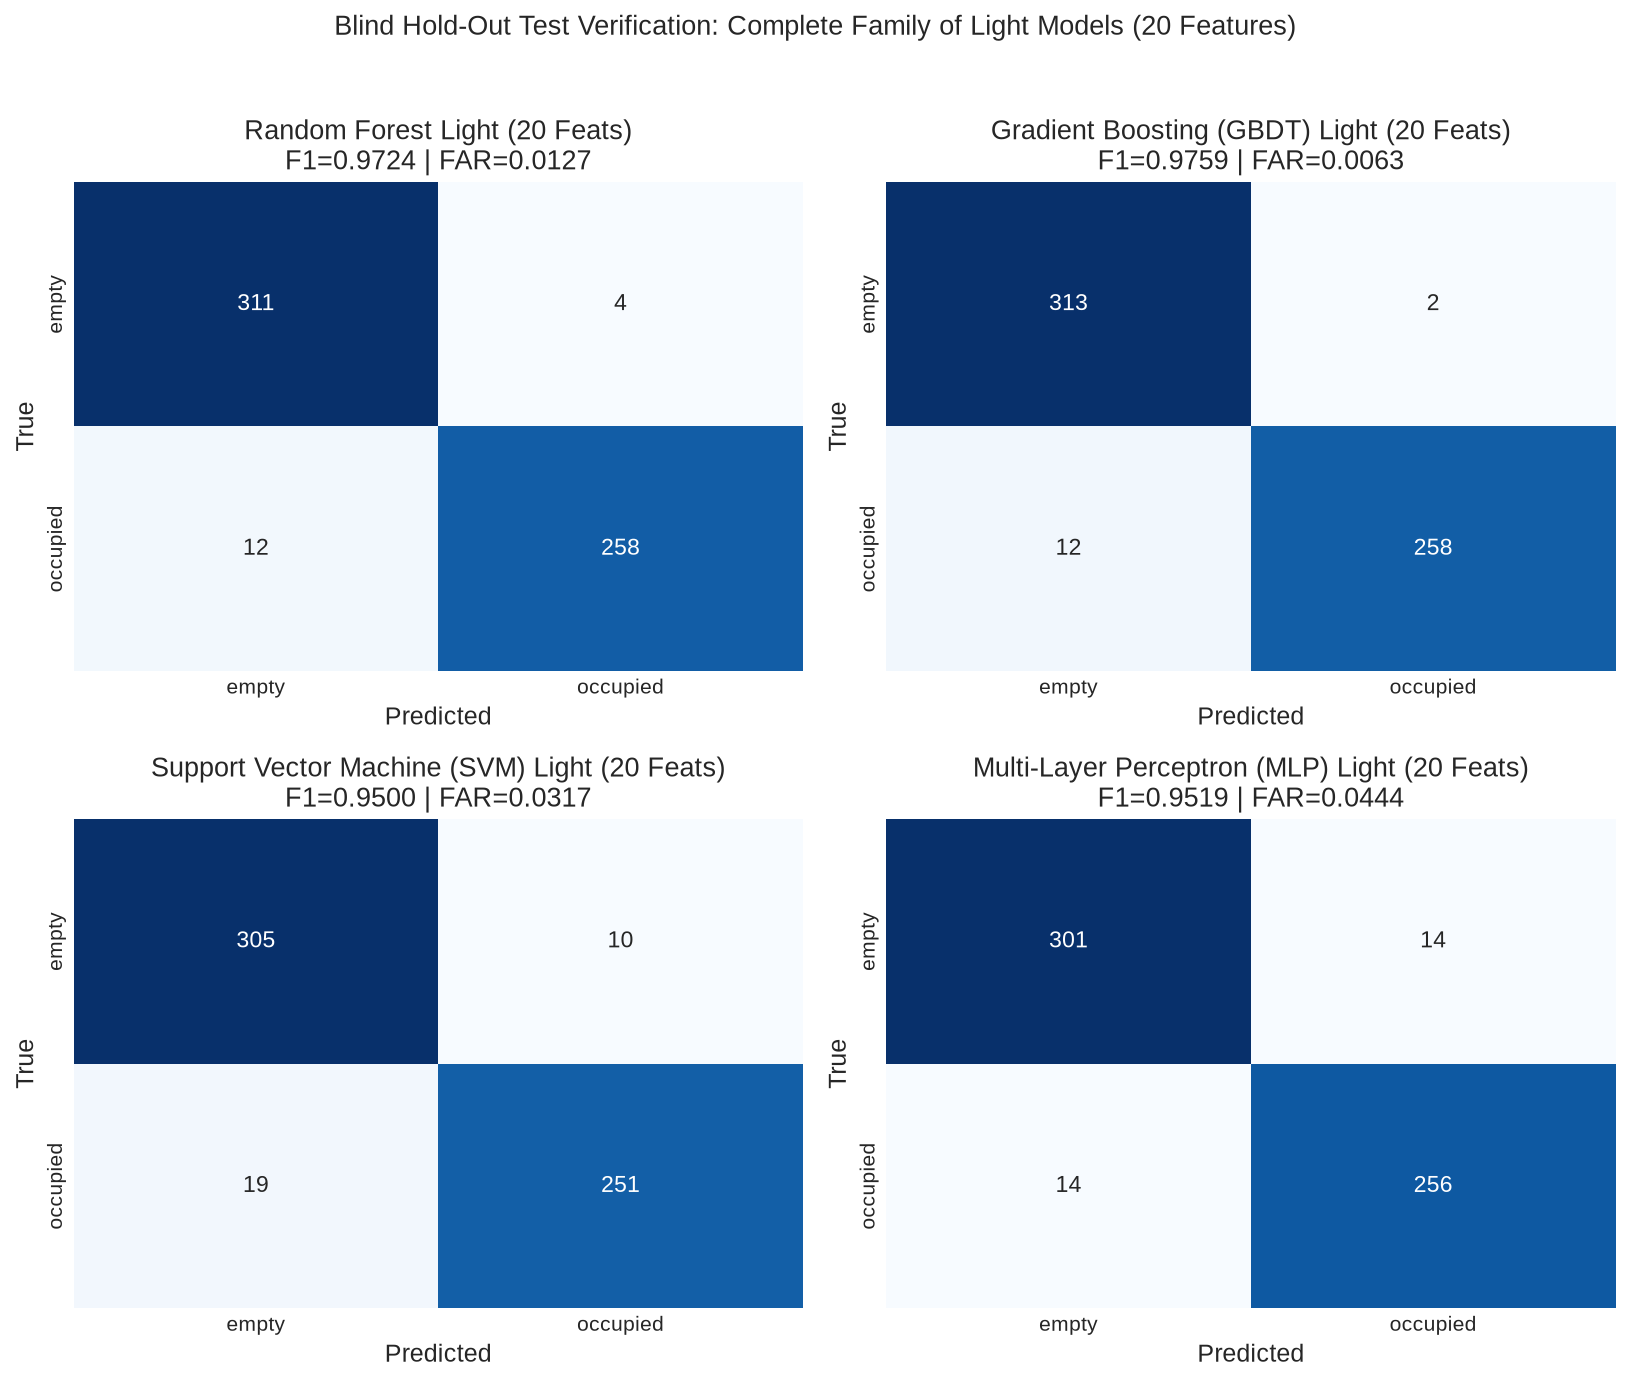

In [8]:
# 1. Evaluate 1-SE Rule on session CV
full_models = ablation_df[ablation_df["n_subcarriers"] == 162]
best_full = full_models.sort_values("mean_f1", ascending=False).iloc[0]
best_model_name = best_full["model"]
full_mean_f1 = best_full["mean_f1"]
full_se_f1 = best_full["se_f1"]

threshold_1se = full_mean_f1 - full_se_f1
tolerance_threshold = full_mean_f1 - 0.01
stopping_threshold = max(threshold_1se, tolerance_threshold)

model_ablation = ablation_df[ablation_df["model"] == best_model_name].sort_values("n_subcarriers")
qualifying = model_ablation[model_ablation["mean_f1"] >= stopping_threshold]

opt_row = qualifying.iloc[0]
opt_n_sc = int(opt_row["n_subcarriers"])
opt_n_feat = int(opt_row["n_features"])

opt_scs = ranked_subcarriers[:opt_n_sc]
opt_features = []
for sc in opt_scs:
    opt_features.extend([f"{sc}_{m}" for m in ["var", "mad", "range", "iqr"]])

raw_sc_indices = [
    int(subcarrier_map.loc[subcarrier_map["valid_subcarrier_index"] == int(s.replace("sc", "")), "raw_subcarrier_index"].iloc[0])
    for s in opt_scs
]

print("=== 1-SE Stopping Rule Evaluation ===")
print(f"Optimal Subcarrier Count N*: {opt_n_sc} subcarriers ({opt_n_feat} features, -96.91% reduction)")
print(f"Selected Subcarriers: {opt_scs}")
print(f"Raw OFDM Subcarrier Indices: {raw_sc_indices}")

# 2. Train & Benchmark Full vs Light Models across All 4 Architectures
from wifi_csi.models.serialization import save_model_bundle

REGISTRY_DIR = ROOT / "models" / "registry"

model_factories = {
    "random_forest": ("Random Forest", lambda: Pipeline([("classifier", RandomForestClassifier(n_estimators=100, max_depth=15, random_state=RANDOM_SEED, n_jobs=-1))])),
    "gradient_boosting": ("Gradient Boosting (GBDT)", lambda: Pipeline([("classifier", HistGradientBoostingClassifier(max_iter=100, learning_rate=0.1, random_state=RANDOM_SEED))])),
    "svm": ("Support Vector Machine (SVM)", lambda: Pipeline([("scaler", StandardScaler()), ("classifier", SVC(C=10, gamma="scale", random_state=RANDOM_SEED))])),
    "mlp": ("Multi-Layer Perceptron (MLP)", lambda: Pipeline([("scaler", StandardScaler()), ("classifier", MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, early_stopping=True, random_state=RANDOM_SEED))])),
}

comparison_rows = []
light_test_preds = {}
light_models_metadata = {}

for base_name, (display_label, factory) in model_factories.items():
    # A. Full Baseline Model (648 features)
    pipe_full = factory()
    pipe_full.fit(X_train_full, y_train)
    
    _ = pipe_full.predict(X_test_full.iloc[:20])
    t0 = time.perf_counter()
    y_pred_full = pipe_full.predict(X_test_full)
    t1 = time.perf_counter()
    lat_full_ms = ((t1 - t0) / len(X_test_full)) * 1000.0
    
    buf = io.BytesIO()
    joblib.dump(pipe_full, buf)
    sz_full_kb = len(buf.getvalue()) / 1024.0
    
    acc_full = accuracy_score(y_test, y_pred_full)
    f1_full = f1_score(y_test, y_pred_full, average="macro")
    far_full = false_alarm_rate(y_test, y_pred_full)
    
    comparison_rows.append({
        "Architecture": display_label,
        "Variant": "Full",
        "Subcarriers": 162,
        "Features": 648,
        "Reduction": "0.0%",
        "Test Macro F1": f"{f1_full:.4f}",
        "Test Accuracy": f"{acc_full:.4f}",
        "FAR": f"{far_full:.4f}",
        "Latency (ms)": f"{lat_full_ms:.4f}",
        "Size (KB)": f"{sz_full_kb:.1f}",
    })
    
    # B. Light Model (20 features)
    pipe_light = factory()
    pipe_light.fit(X_train_full[opt_features], y_train)
    
    _ = pipe_light.predict(X_test_full[opt_features].iloc[:20])
    t0 = time.perf_counter()
    y_pred_light = pipe_light.predict(X_test_full[opt_features])
    t1 = time.perf_counter()
    lat_light_ms = ((t1 - t0) / len(X_test_full)) * 1000.0
    
    buf_l = io.BytesIO()
    joblib.dump(pipe_light, buf_l)
    sz_light_kb = len(buf_l.getvalue()) / 1024.0
    
    acc_light = accuracy_score(y_test, y_pred_light)
    f1_light = f1_score(y_test, y_pred_light, average="macro")
    far_light = false_alarm_rate(y_test, y_pred_light)
    
    light_name = f"{base_name}_light"
    light_test_preds[light_name] = (y_pred_light, f1_light, far_light, display_label)
    
    comparison_rows.append({
        "Architecture": display_label,
        "Variant": "Light",
        "Subcarriers": opt_n_sc,
        "Features": opt_n_feat,
        "Reduction": "96.9%",
        "Test Macro F1": f"{f1_light:.4f}",
        "Test Accuracy": f"{acc_light:.4f}",
        "FAR": f"{far_light:.4f}",
        "Latency (ms)": f"{lat_light_ms:.4f}",
        "Size (KB)": f"{sz_light_kb:.1f}",
    })
    
    # Save flat pickle
    joblib.dump(pipe_light, MODELS_DIR / f"{light_name}.pkl")
    
    # Package into model bundle
    bundle_meta = {
        "is_light": True,
        "is_reduced": True,
        "parent_model": base_name,
        "optimal_subcarriers": opt_scs,
        "raw_subcarrier_indices": raw_sc_indices,
        "feature_columns": opt_features,
        "n_subcarriers": opt_n_sc,
        "n_features": opt_n_feat,
        "reduction_pct": 96.91,
        "accuracy": round(float(acc_light), 4),
        "f1_macro": round(float(f1_light), 4),
        "false_alarm_rate": round(float(far_light), 4),
        "latency_ms": round(float(lat_light_ms), 4),
        "size_kb": round(float(sz_light_kb), 1),
        "test_metrics": {
            "accuracy": round(float(acc_light), 4),
            "f1_macro": round(float(f1_light), 4),
            "false_alarm_rate": round(float(far_light), 4),
        },
    }
    
    save_model_bundle(
        pipeline=pipe_light,
        name=light_name,
        output_dir=REGISTRY_DIR,
        metadata=bundle_meta,
        save_legacy_flat=False,
    )
    
    light_models_metadata[base_name] = {
        "full": {
            "accuracy": round(float(acc_full), 4),
            "f1_macro": round(float(f1_full), 4),
            "false_alarm_rate": round(float(far_full), 4),
            "latency_ms": round(float(lat_full_ms), 4),
            "size_kb": round(float(sz_full_kb), 1),
        },
        "light": {
            "accuracy": round(float(acc_light), 4),
            "f1_macro": round(float(f1_light), 4),
            "false_alarm_rate": round(float(far_light), 4),
            "latency_ms": round(float(lat_light_ms), 4),
            "size_kb": round(float(sz_light_kb), 1),
        }
    }

# Identify top performer per modality
best_light_key = max(light_models_metadata.keys(), key=lambda k: light_models_metadata[k]["light"]["f1_macro"])
best_light_model = f"{best_light_key}_light"
best_standard_model = "mlp"

# Display Side-by-Side Comparison Table
comp_table_df = pd.DataFrame(comparison_rows)
print("\n" + "="*85)
print("  BLIND TEST BENCHMARK: FULL (648 FEATS) VS. LIGHT (20 FEATS) MODEL FAMILY")
print("="*85)
print(comp_table_df.to_string(index=False))
print("="*85)

# Visual Verification: 2x2 Grid of Confusion Matrices for All 4 Light Models
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes_flat = axes.ravel()

for idx, (m_key, (preds, f1_val, far_val, label)) in enumerate(light_test_preds.items()):
    ax = axes_flat[idx]
    plot_confusion_matrix(
        y_test,
        preds,
        ax=ax,
        title=f"{label} Light (20 Feats)\nF1={f1_val:.4f} | FAR={far_val:.4f}"
    )

fig.suptitle("Blind Hold-Out Test Verification: Complete Family of Light Models (20 Features)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "feature_minimization_confusion_matrices.png", dpi=300)
fig.savefig(FIG_DIR / "feature_minimization_confusion_matrices.pdf")
plt.show()


## 6. Artifact Export & Technical Summary
We export the exact operational metadata, subcarrier index mappings, and benchmark metrics for all models in the light family to `optimal_features.json`. This provides single-source-of-truth metadata for deployment in real-time inference scripts and embedded firmware.

In [ ]:
best_light_key = max(light_models_metadata.keys(), key=lambda k: light_models_metadata[k]["light"]["f1_macro"])
best_light_bundle = f"{best_light_key}_light"

optimal_record = {
    "optimal_subcarriers": opt_scs,
    "optimal_subcarrier_indices": [int(s.replace("sc", "")) for s in opt_scs],
    "raw_subcarrier_indices": raw_sc_indices,
    "optimal_feature_columns": opt_features,
    "num_subcarriers": opt_n_sc,
    "num_features": opt_n_feat,
    "full_features": 648,
    "reduction_pct": 96.91,
    "best_standard_model": "mlp",
    "best_light_model": best_light_bundle,
    "best_model_architecture": best_model_name,
    "stopping_criterion": {
        "full_baseline_cv_f1": round(float(full_mean_f1), 4),
        "full_baseline_se": round(float(full_se_f1), 4),
        "one_se_threshold": round(float(threshold_1se), 4),
        "operational_threshold": round(float(stopping_threshold), 4),
        "reduced_model_cv_f1": round(float(opt_row["mean_f1"]), 4),
    },
    "test_metrics_full": light_models_metadata[best_light_key]["full"],
    "test_metrics_reduced": light_models_metadata[best_light_key]["light"],
    "light_models": light_models_metadata,
    "best_light_model": best_light_bundle,
}

with open(LOGS_DIR / "optimal_features.json", "w") as f:
    json.dump(optimal_record, f, indent=2)

# with open(ROOT / "optimal_features.json", "w") as f:
#     json.dump(optimal_record, f, indent=2)

# with open(MODELS_DIR / "optimal_features.json", "w") as f:
#     json.dump(optimal_record, f, indent=2)

print(f"Exported optimal features configuration for all Light Models to:")
print(f"  - {LOGS_DIR / 'optimal_features.json'}")
# print(f"  - {ROOT / 'optimal_features.json'}")
# print(f"  - {MODELS_DIR / 'optimal_features.json'}")
print(f"Best performing light architecture: {best_light_bundle}")
print(json.dumps(optimal_record, indent=2))


Exported optimal features configuration for all Light Models to:
  - /home/xavier/dev/wifi-csi-presence-detection/reports/logs/optimal_features.json
  - /home/xavier/dev/wifi-csi-presence-detection/optimal_features.json
  - /home/xavier/dev/wifi-csi-presence-detection/models/optimal_features.json
Best performing light architecture: gradient_boosting_light
{
  "optimal_subcarriers": [
    "sc041",
    "sc040",
    "sc042",
    "sc047",
    "sc012"
  ],
  "optimal_subcarrier_indices": [
    41,
    40,
    42,
    47,
    12
  ],
  "raw_subcarrier_indices": [
    48,
    47,
    49,
    54,
    18
  ],
  "optimal_feature_columns": [
    "sc041_var",
    "sc041_mad",
    "sc041_range",
    "sc041_iqr",
    "sc040_var",
    "sc040_mad",
    "sc040_range",
    "sc040_iqr",
    "sc042_var",
    "sc042_mad",
    "sc042_range",
    "sc042_iqr",
    "sc047_var",
    "sc047_mad",
    "sc047_range",
    "sc047_iqr",
    "sc012_var",
    "sc012_mad",
    "sc012_range",
    "sc012_iqr"
  ],
  "num_